In [4]:
import numpy as np
import scipy
from Scripts.Optimization.optimization import Optimizer
from Scripts.Finite_Elements.Beam_FEA_System.beam_type import BeamType
from Scripts.Finite_Elements.Beam_FEA_System.beam_system import BeamSystem
from Scripts.Finite_Elements.material_properties import Materials


In [5]:
opt = Optimizer()
opt.independent_properties_calc()
print(opt.mission_profile.duration)
opt.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.6,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 475,
    "hub_radius": 250,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

res = opt.run_opt()

x = np.array(res.x)
x_expanded = list(opt.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt.test_results(x)


dv_keys = list(opt.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"mass w/ payload: {res.fun * 1000} kg")


print("OPT_OUTPUT")
opt.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

640
Positive directional derivative for linesearch
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.2540000000000008
   strut_diameter: 50.0
   strut_thickness: 0.2540000000000002
   strut_distance: 454.2624850257739
   hub_radius: 250
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 1.0000000000000078
   stress: 0.8763661383057956
   displacement amplitude: 0.17652035137573405
   energy: 0.8904864121879814
   damage: 0.0
mass w/ payload: 485.04051678727524 kg
OPT_OUTPUT
Initial guess opt actual:
[2.54000000e-01 2.54000000e-01 4.54262485e+02]


In [3]:
import os
import pandas as pd

table_path = "Tables/Sensitivity_Testing_Ver_2.csv"

for i in range(8):
    case_title = "Case " + str(i)
    x2 = [
        ((x[0] - 0.001 * x[0])) if i in (0, 1, 2, 3) else (x[0] + 0.001 * x[0]),
        ((x[1] - 0.001 * x[1])) if i in (0, 1, 4, 5) else (x[1] + 0.001 * x[1]),
        ((x[2] - 0.001 * x[2])) if i in (0, 3, 5, 7) else (x[2] + 0.001 * x[2])
    ]
    print(x2)
    cons_res_opt, cons_labels_opt = opt.test_results(x2)
    mass = opt.mass(opt.reform_dvs(x2))

    data = {}
    data.update(opt.reform_dvs(x2))
    opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
    data.update(opt_dictionary)
    data.update({"mass": mass * 1000})

    print(data)

    # Ensure directory exists
    os.makedirs(os.path.dirname(table_path), exist_ok=True)

    new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

    if os.path.exists(table_path):
        try:
            df_existing = pd.read_csv(table_path, index_col=0)
        except Exception:
            df_existing = pd.DataFrame()

        if df_existing.empty:
            df = new_col_df
        else:
            for idx in new_col_df.index:
                if idx not in df_existing.index:
                    df_existing.loc[idx] = pd.NA
            df_existing[case_title] = new_col_df[case_title]
            df = df_existing
    else:
        df = new_col_df

    df.to_csv(table_path, index=True)


[np.float64(0.3019488863722513), np.float64(0.36053487938214956), np.float64(556.2306003338063)]
{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.3019488863722513), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36053487938214956), 'strut_distance': np.float64(556.2306003338063), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(1.001238748777397), 'stress': np.float64(0.9790032595698512), 'displacement amplitude': np.float64(0.6880215188266572), 'energy': np.float64(0.32588950602437217), 'damage': np.float64(0.0), 'mass': np.float64(0.8240765473051699)}
[np.float64(0.3019488863722513), np.float64(0.36053487938214956), np.float64(557.3441751092494)]
{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.3019488863722513), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36053487938214956), 'strut_distance': np.float64(557.3441751092494), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'defl

In [4]:
import os
import pandas as pd
table_path = "Tables/Sensitivity_Testing_Ver_2.csv"
case_title = "Optimal Point"

mass = opt.mass(opt.reform_dvs(x))

data = {}
data.update(opt.reform_dvs(x))
opt_dictionary = dict(zip(cons_labels_opt, cons_res_opt))
data.update(opt_dictionary)
data.update({"mass":mass * 1000})

print(data)

# Ensure directory exists
os.makedirs(os.path.dirname(table_path), exist_ok=True)

new_col_df = pd.DataFrame.from_dict(data, orient="index", columns=[case_title])

if os.path.exists(table_path):
    try:
        df_existing = pd.read_csv(table_path, index_col=0)
    except Exception:
        df_existing = pd.DataFrame()

    if df_existing.empty:
        df = new_col_df
    else:
        for idx in new_col_df.index:
            if idx not in df_existing.index:
                df_existing.loc[idx] = pd.NA
        df_existing[case_title] = new_col_df[case_title]
        df = df_existing
else:
    df = new_col_df

df.to_csv(table_path, index=True) 


{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.30225113750976107), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.36089577515730686), 'strut_distance': np.float64(556.7873877215278), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7, 'deflection': np.float64(0.9993820893945647), 'stress': np.float64(0.9770362886003495), 'displacement amplitude': np.float64(0.6797064373372121), 'energy': np.float64(0.32589463889464126), 'damage': np.float64(0.0), 'mass': np.float64(0.8250114545173702)}


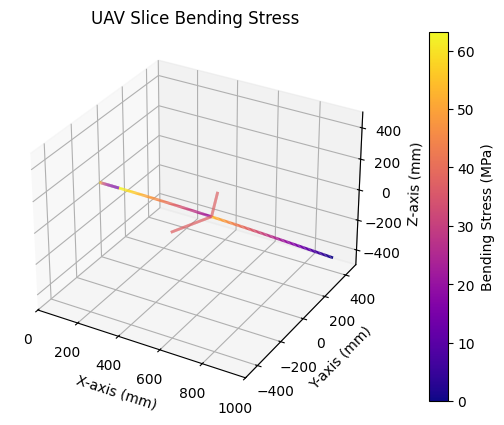

In [5]:
from Scripts.visualization import drone_geometry_stress

drone_geometry_stress(opt.fea, 1, 100)

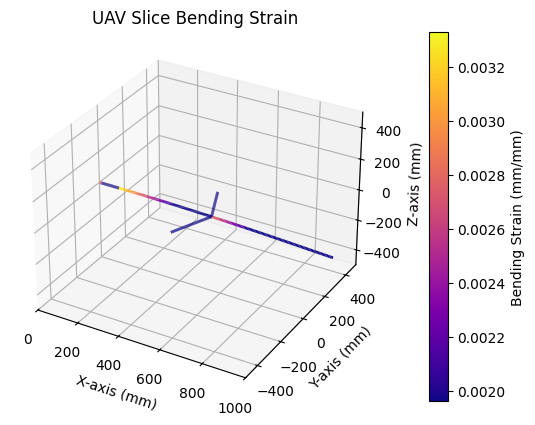

In [6]:
from Scripts.visualization import drone_geometry_strain

drone_geometry_strain(opt.fea, 1, 100)

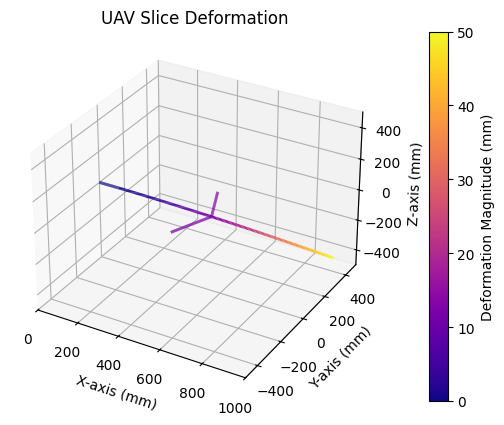

In [7]:
from Scripts.visualization import drone_geometry_deformation

drone_geometry_deformation(opt.fea, 1, 100)

In [8]:
import Scripts.unit_conversions as uc
opt.fea.beam_system.solve_natural_frequencies()
print(f"First Nf: {opt.fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {opt.fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")

First Nf: 24.247720460214193 Hz
Second Nf: 55.42780364276522 Hz


In [9]:
print(352.7148774623214 * uc.rad_per_s_to_Hz)

print(max(opt.fea.beam_system.mag_displacements_amplitude))

56.1363162501806
52.27863351822437


{'arm_diameter': 50.0, 'arm_thickness': 0.30225113750976107, 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.5), 'strut_distance': np.float64(600.0), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


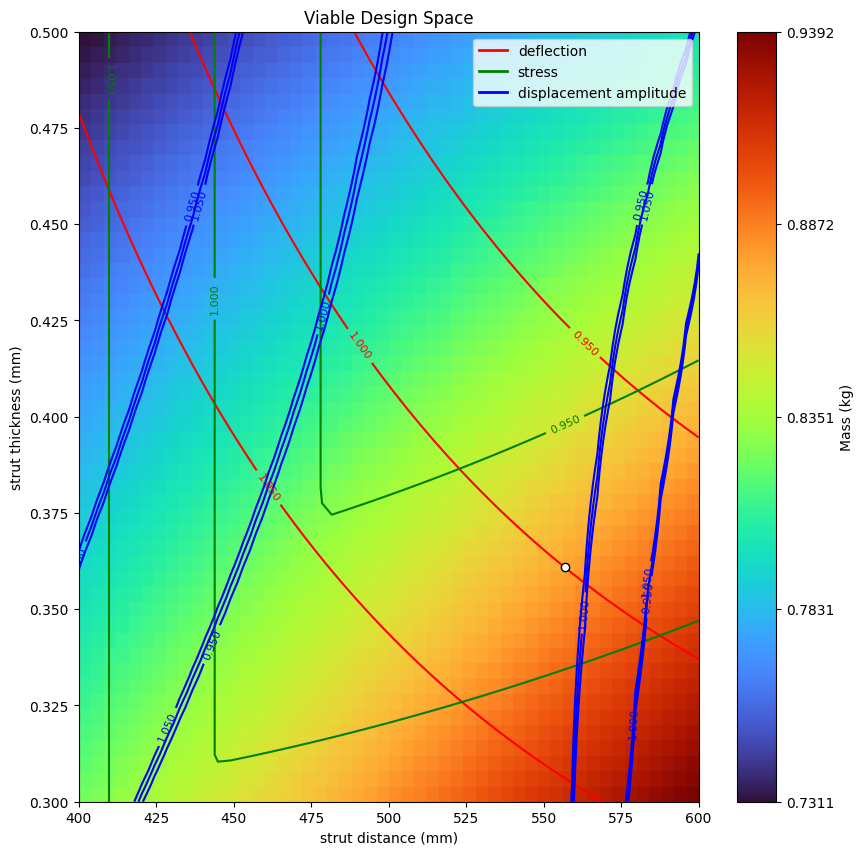

In [10]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 50, design_variables, (400, 600), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.5), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.5), 'strut_distance': 556.7873877215278, 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


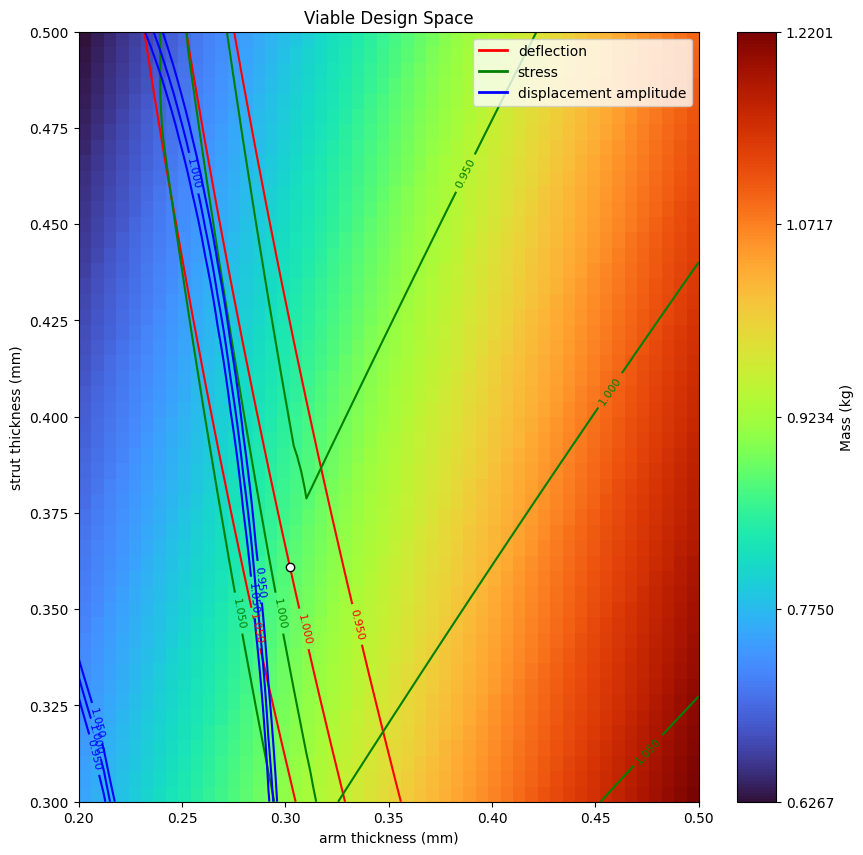

In [11]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 50, design_variables, (0.2, 0.5), (0.3, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

{'arm_diameter': 50.0, 'arm_thickness': 0.30225113750976107, 'strut_diameter': 50.0, 'strut_thickness': np.float64(3.175), 'strut_distance': np.float64(1127.3), 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


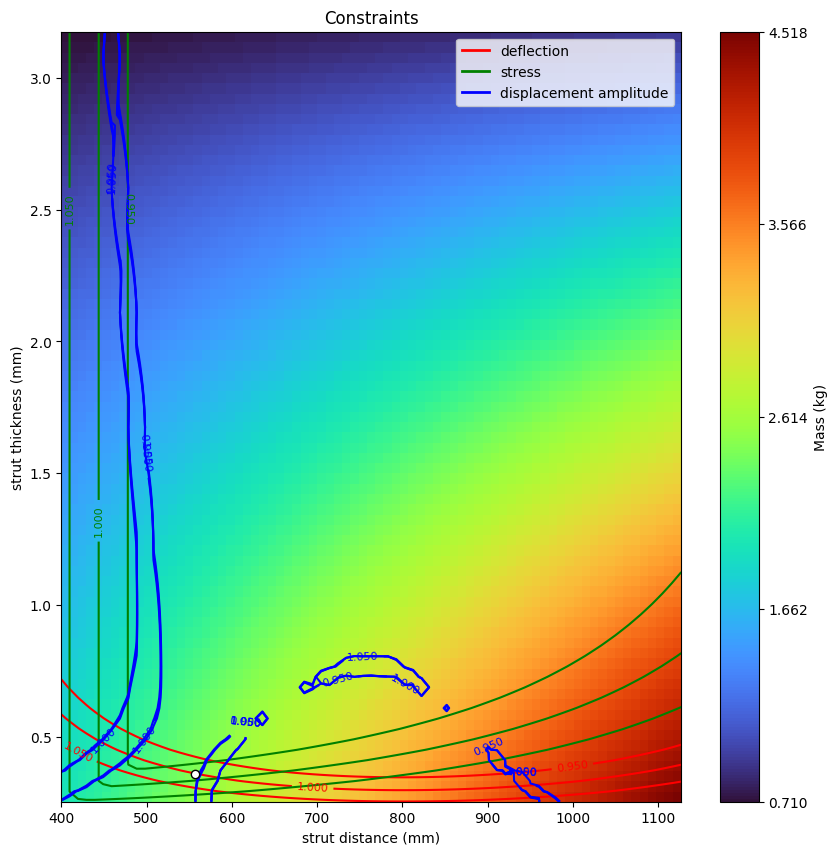

In [12]:
# zoomed out
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "strut_distance", "strut_thickness", 75, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

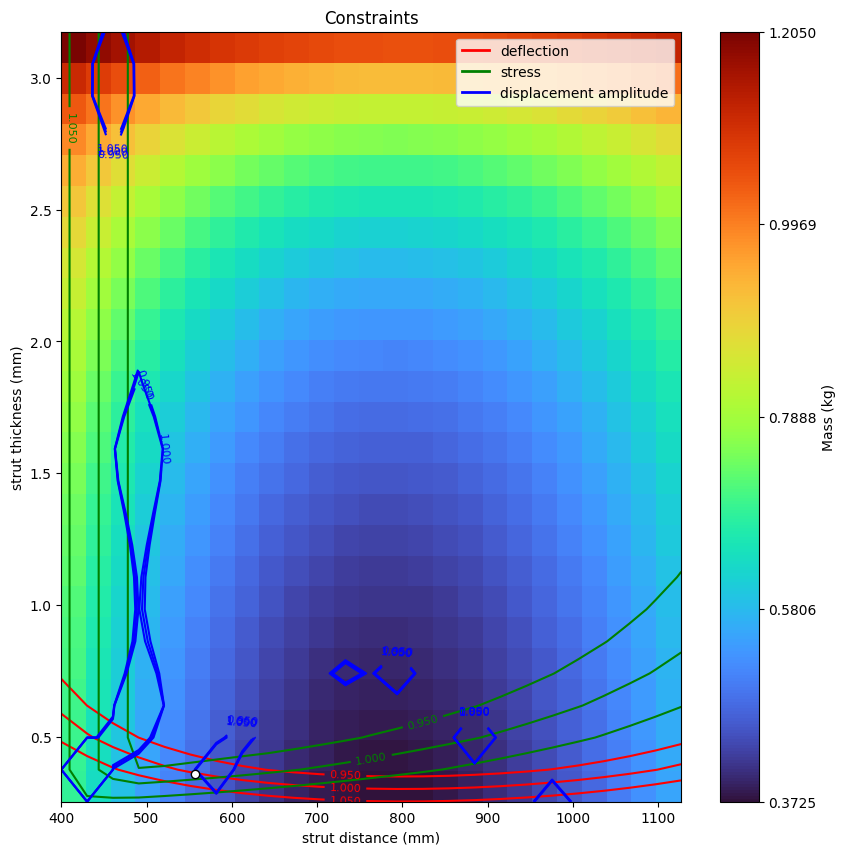

In [13]:
# TEST
from Scripts.visualization import design_space_test_cons
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_test_cons(opt, "strut_distance", "strut_thickness", 25, design_variables, None,None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[4], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

In [14]:
design_variables = {
    "arm_diameter": x_expanded[0],
    "arm_thickness": x_expanded[1],
    "strut_diameter": x_expanded[2],
    "strut_thickness": 1.75,
    "strut_distance": 1100,
    "hub_radius": x_expanded[5],
    "hub_flange_thickness": x_expanded[6],
    "hub_web_thickness": x_expanded[7]
}
active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}
constraints_res, labels = opt.constraint_calculations(design_variables, active_constraints, True)
for i in range(len(constraints_res)):
    print(f"{labels[i]}: {constraints_res[i]}")

deflection: 0.6149177853712312
stress: 0.8899480537968972
displacement amplitude: 0.02880127280218797


{'arm_diameter': 50.0, 'arm_thickness': np.float64(3.175), 'strut_diameter': 50.0, 'strut_thickness': np.float64(3.175), 'strut_distance': 556.7873877215278, 'hub_radius': 100.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


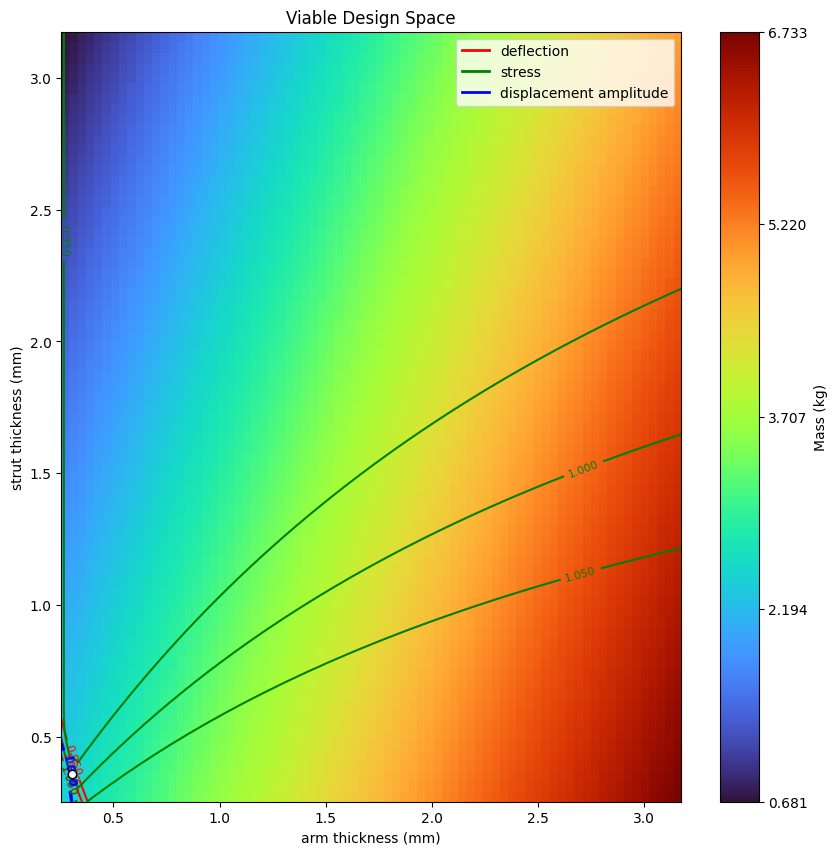

In [15]:
# plot the space
from Scripts.visualization import design_space_mass
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_mass(opt, "arm_thickness", "strut_thickness", 75, design_variables, None, None, {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100) # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

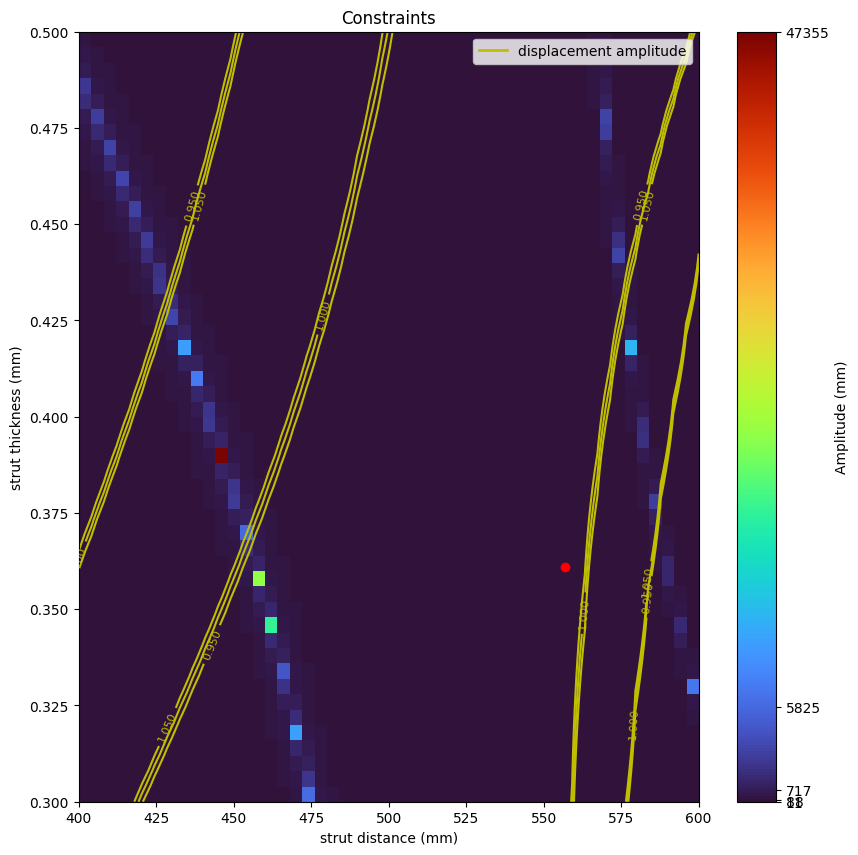

In [16]:
# plot the space
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 50, design_variables,(400,600),(0.3,0.5),{
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

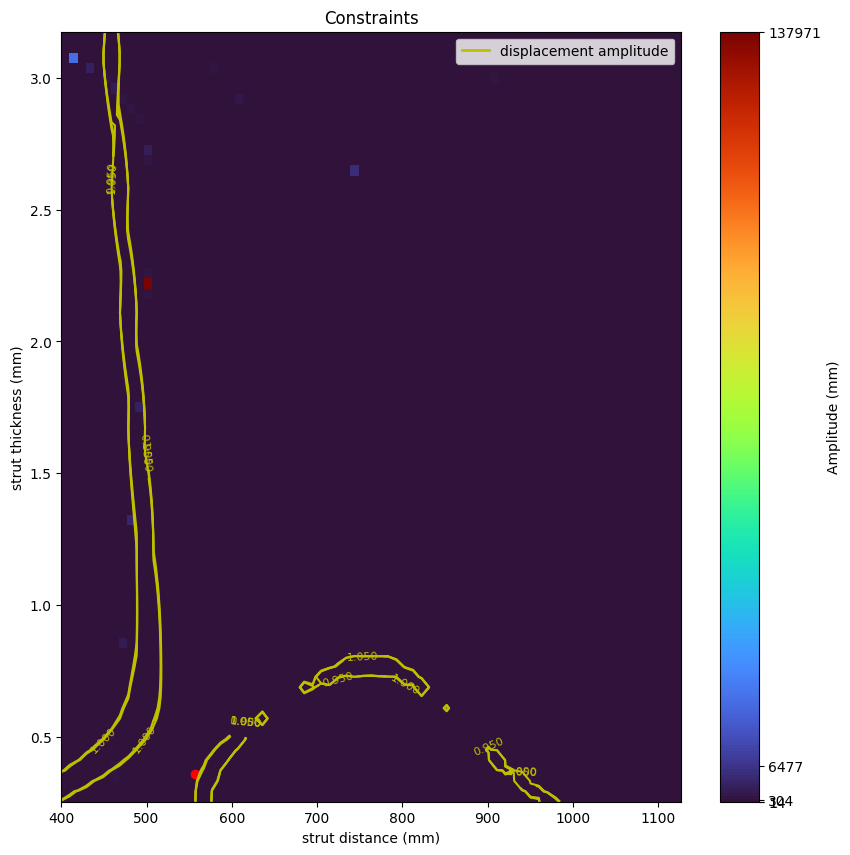

In [17]:

# zoomed out
from Scripts.visualization import design_space_freq
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_freq(opt, "strut_distance", "strut_thickness", 75, design_variables,None,None, {
    "deflection": False,
    "stress": False,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
plt.scatter(x_expanded[4], x_expanded[3], c='r')
plt.title('Constraints')
plt.xlabel('strut distance (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

Initial guess 1 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 25,
    "strut_diameter": 50.0,
    "strut_thickness": 25,
    "strut_distance": 510,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31612437848973063
   strut_diameter: 50.0
   strut_thickness: 0.3602027837054039
   strut_distance: 509.98696996881597
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999970214
   stress: 0.955560709497491
   frequency: 0.26171190065852373
   energy: 0.326065371252493
   damage: 0.0
mass w/ payload: 0.8265042304244963 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16124378e-01 3.60202784e-01 5.09986970e+02]

Initial guess 2 tol=e-12

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 1,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}


===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.3022755041161241
   strut_diameter: 50.0
   strut_thickness: 0.3608985852993385
   strut_distance: 556.6928996805128
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.9999999999999539
   stress: 0.9780731466461088
   frequency: 0.2914667465901592
   energy: 0.3260612237046038
   damage: 0.0
mass w/ payload: 0.8250114520506969 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275504e-01 3.60898585e-01 5.56692900e+02]

Inital Guess 3 tol=1e-18

Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.30227574532156787
   strut_diameter: 50.0
   strut_thickness: 0.3608980022929013
   strut_distance: 556.6928997650245
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.999999999999994
   stress: 0.9780730549779
   frequency: 0.29146623894235507
   energy: 0.32606122370460633
   damage: 0.0
mass w/ payload: 0.8250114520506582 kg
OPT_OUTPUT
Initial guess opt actual:
[3.02275745e-01 3.60898002e-01 5.56692900e+02]

Initial Guess 4 tol=1e-18

opt.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.6,
    "strut_distance": 425,
    "hub_radius": 100.0,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

Positive directional derivative for linesearch
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.31654251873360006
   strut_diameter: 50.0
   strut_thickness: 0.48657929350939877
   strut_distance: 412.17184660354866
   hub_radius: 100.0
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 1.0000000000000013
   stress: 1.0000000000000078
   frequency: 1.0000000000001152
   energy: 0.3261353943704316
   damage: 0.0
mass w/ payload: 0.8461615400019418 kg
OPT_OUTPUT
Initial guess opt actual:
[3.16542519e-01 4.86579294e-01 4.12171847e+02]

In [18]:
import Scripts.Finite_Elements.drone_fea as fea
import Scripts.unit_conversions as uc
uav_geo = opt.drone_geometry
uav_fea = fea.DroneFEA(uav_geo)
uav_fea.create_drone_nodes()
uav_fea.create_drone_beams()
# uav_fea.boundary_conditions()
uav_fea.solve_fea()
uav_fea.beam_system.solve_natural_frequencies()
np.set_printoptions(precision=3,suppress=True)
print(f"First Nf: {uav_fea.beam_system.natural_frequencies[0] * uc.rad_per_s_to_Hz} Hz")
print(f"Second Nf: {uav_fea.beam_system.natural_frequencies[1] * uc.rad_per_s_to_Hz} Hz")
print(f"Third Nf: {uav_fea.beam_system.natural_frequencies[2] * uc.rad_per_s_to_Hz} Hz")
print(f"Fourth Nf: {uav_fea.beam_system.natural_frequencies[3] * uc.rad_per_s_to_Hz} Hz")
print(f"Nf: {uav_fea.beam_system.natural_frequencies * uc.rad_per_s_to_Hz} Hz")

First Nf: 0.0 Hz
Second Nf: 0.0 Hz
Third Nf: 0.0 Hz
Fourth Nf: 0.000795635714783167 Hz
Nf: [0.000e+00 0.000e+00 0.000e+00 7.956e-04 1.476e-02 1.061e-01 1.399e+01
 1.399e+01 2.740e+01 2.845e+01 2.845e+01 3.558e+01 3.593e+01 3.912e+01
 3.912e+01 4.078e+01 4.078e+01 4.685e+01 4.685e+01 4.904e+01 5.000e+01
 5.000e+01 5.058e+01 5.159e+01 5.176e+01 5.176e+01 5.313e+01 5.313e+01
 5.423e+01 5.440e+01 5.440e+01 5.494e+01 5.494e+01 5.606e+01 5.606e+01
 5.884e+01 5.884e+01 6.341e+01 7.242e+01 7.243e+01 7.243e+01 9.129e+01
 9.129e+01 1.086e+02 1.086e+02 1.151e+02 1.481e+02 1.481e+02 1.481e+02
 1.482e+02 1.482e+02 1.482e+02 1.912e+02 1.912e+02 2.126e+02 2.126e+02
 2.190e+02 4.588e+02 4.588e+02 4.952e+02 5.349e+02 5.349e+02 5.349e+02
 5.349e+02 5.349e+02 5.349e+02 5.349e+02 5.349e+02 5.777e+02 7.248e+02
 7.248e+02 7.477e+02 7.477e+02 7.477e+02 7.477e+02 7.477e+02 1.005e+03
 1.005e+03 1.167e+03 1.167e+03 1.226e+03 1.226e+03 1.308e+03 1.620e+03
 1.620e+03 2.187e+03 2.187e+03 2.187e+03 2.187e+03 2.187e

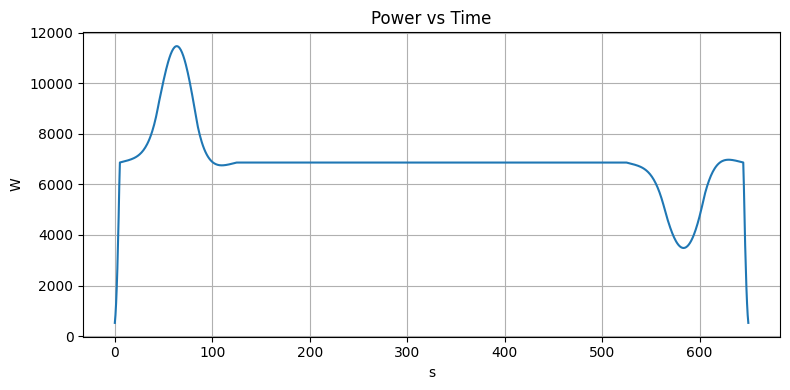

In [7]:
import matplotlib.pyplot as plt
import Scripts.unit_conversions as uc

drone_power = opt.drone_power_module
m1 = opt.mission_profile

power_list = drone_power.timesteps.copy()
thrust_list = drone_power.timesteps.copy()
osc_list = drone_power.timesteps.copy()
time_list = drone_power.timesteps.copy()
drone_mass = opt.drone_mass
surface_area = opt.surface_area
for i, t in enumerate(time_list):
    power_list[i] = drone_power.power_at_time(t)
    thrust_list[i] = opt.total_force_y(t, drone_mass, surface_area)
    osc_list[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)


print(opt.mission_profile)
# Power vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Power vs Time")
plt.plot(time_list, power_list / 1000)
plt.grid()
plt.ylabel("W")
plt.xlabel("s")
plt.tight_layout()
plt.show()

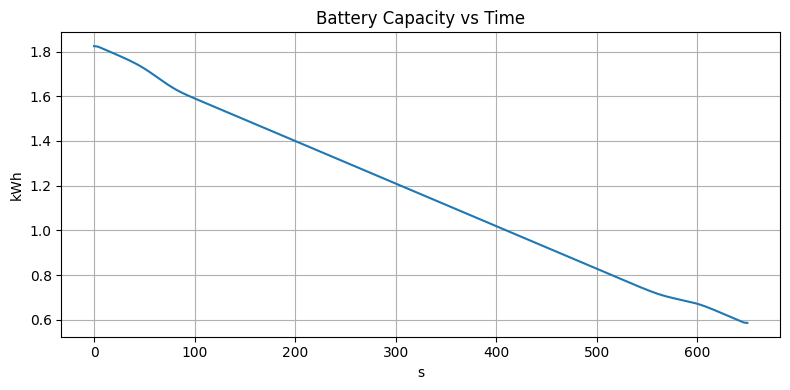

In [4]:

# Battery Capacity vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Battery Capacity vs Time")
plt.plot(drone_power.timesteps, drone_power.energy_remaining * uc.s_to_hrs * uc.mW_to_kW)
plt.grid()
plt.ylabel("kWh")
plt.xlabel("s")
plt.tight_layout()
plt.show()

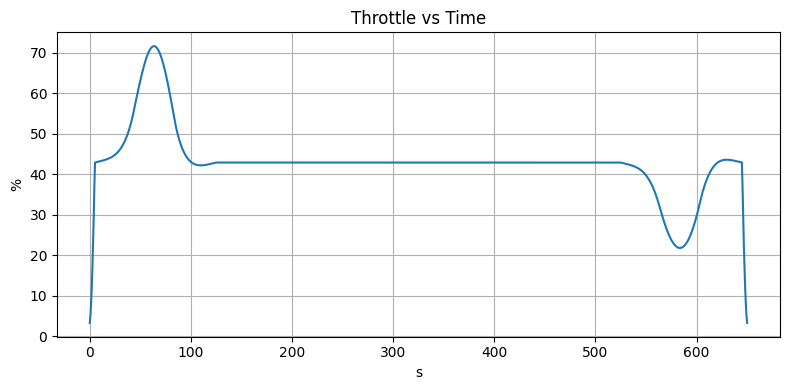

In [5]:

# Throttle vs Time - separate figure
plt.figure(figsize=(8, 4))
plt.title("Throttle vs Time")
plt.plot(drone_power.timesteps, drone_power.percent_throttle * 100)
plt.grid()
plt.ylabel("%")
plt.xlabel("s")
plt.tight_layout()
plt.show()


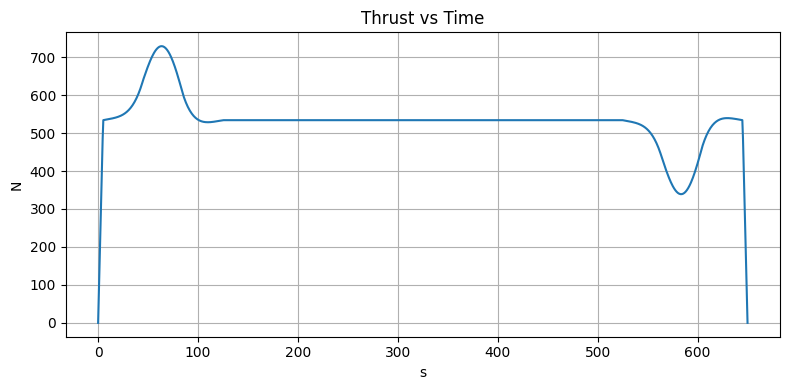

In [6]:
plt.figure(figsize=(8, 4))
plt.title("Thrust vs Time")
plt.plot(time_list, thrust_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

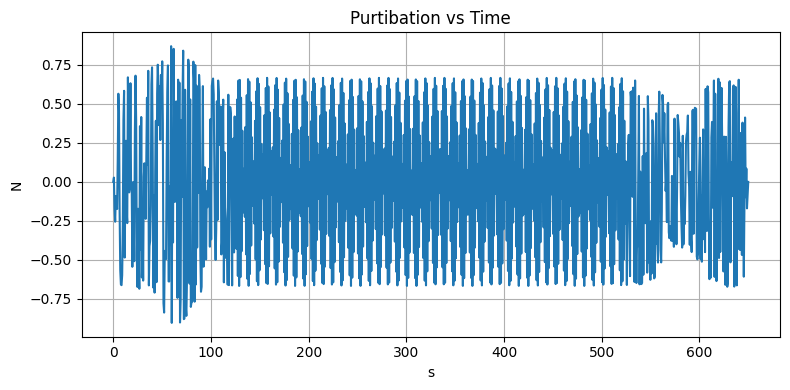

In [9]:
plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list, osc_list)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

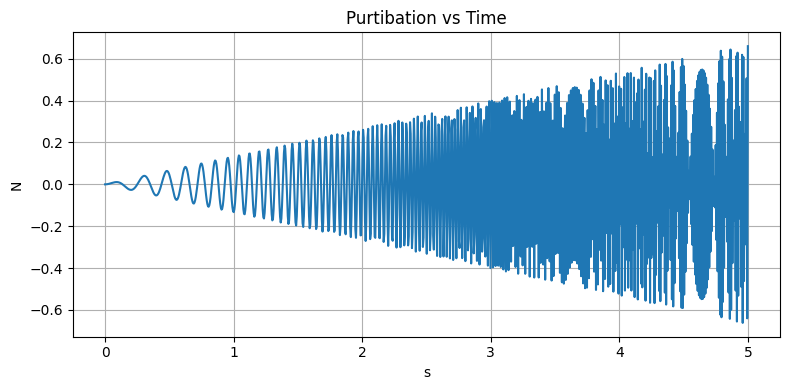

In [26]:

time_list_2 = np.linspace(0, 5, 1000)
osc_list_2 = np.zeros(len(time_list_2))
for i, t in enumerate(time_list_2):
    osc_list_2[i] = opt.force_oscillation_transient(t, drone_power, drone_mass, surface_area)

plt.figure(figsize=(8, 4))
plt.title("Purtibation vs Time")
plt.plot(time_list_2, osc_list_2)
plt.grid()
plt.ylabel("N")
plt.xlabel("s")
plt.tight_layout()
plt.show()

{'arm_diameter': 50.0, 'arm_thickness': np.float64(0.5), 'strut_diameter': 50.0, 'strut_thickness': np.float64(0.5), 'strut_distance': 454.2624850257739, 'hub_radius': 250.0, 'hub_flange_thickness': 0.7, 'hub_web_thickness': 0.7}


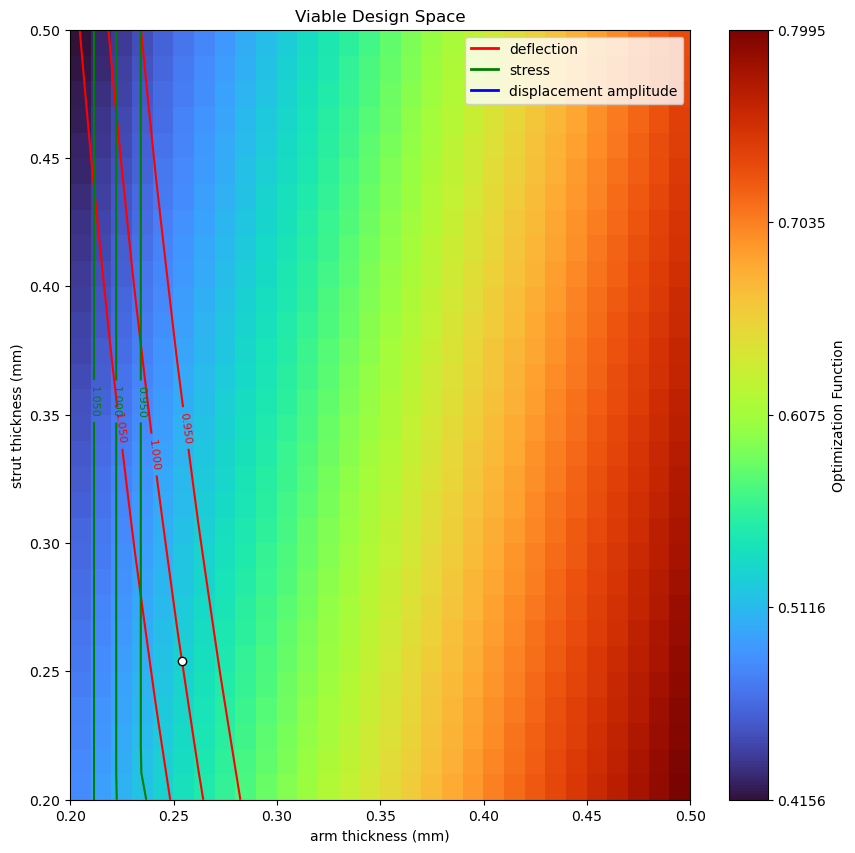

In [6]:
# plot the space
from Scripts.visualization import design_space_obj
import matplotlib.pyplot as plt

design_variables = {dv_keys[i]: float(x_expanded[i]) for i in range(len(dv_keys))}

design_space_obj(opt, "arm_thickness", "strut_thickness", 30, design_variables, (0.2, 0.5), (0.2, 0.5), {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
})
ax = plt.gca()
plt.scatter(x_expanded[1], x_expanded[3], c='white', edgecolor='k', zorder=100)  # check this

ax.set_axisbelow(False)
plt.title('Viable Design Space')
plt.xlabel('arm thickness (mm)')
plt.ylabel('strut thickness (mm)')
plt.show()

In [8]:

opt2 = Optimizer()
opt2.independent_properties_calc()
print(opt.mission_profile.duration)
opt2.active_constraints = {
    "deflection": True,
    "stress": True,
    "frequency": True,
    "natural frequency": False,
    "energy": False,
    "damage": False,
}

opt2.design_variables_initial_guess = {
    "arm_diameter": 50.0,
    "arm_thickness": 0.3,
    "strut_diameter": 50.0,
    "strut_thickness": 0.3,
    "strut_distance": 475,
    "hub_radius": 250,
    "hub_flange_thickness": 0.7,
    "hub_web_thickness": 0.7
}

res = opt2.run_opt()

x = np.array(res.x)
x_expanded = list(opt2.reform_dvs(x).values())

'''
opt.fixed_design_variables = {
    "arm_diameter": False,
    "arm_thickness": False,
    "strut_diameter": False,
    "strut_thickness": False,
    "strut_distance": False,
    "hub_radius": False,
    "hub_flange_thickness": False,
    "hub_web_thickness": False
}
'''

cons_res_opt, cons_labels_opt = opt2.test_results(x)

dv_keys = list(opt2.design_variables_initial_guess.keys())

print("===== Optimized =====")
print("design variables")
for i in range(len(dv_keys)):
    print(f"   {dv_keys[i]}: {x_expanded[i]}")

print("constraints")
for i in range(len(cons_res_opt)):
    print(f"   {cons_labels_opt[i]}: {cons_res_opt[i]}")

print(f"mass w/ payload: {res.fun * 1000} kg")

print("OPT_OUTPUT")
opt2.test_results(x, detailed_output=True)

print("Initial guess opt actual:")
print(res.x)

640
Optimization terminated successfully
===== Optimized =====
design variables
   arm_diameter: 50.0
   arm_thickness: 0.254
   strut_diameter: 50.0
   strut_thickness: 0.254
   strut_distance: 454.26248502578306
   hub_radius: 250
   hub_flange_thickness: 0.7
   hub_web_thickness: 0.7
constraints
   deflection: 0.99999999999999
   stress: 0.8763661383057834
   displacement amplitude: 0.17652035137573996
   energy: 0.8904864121879816
   damage: 0.0
mass w/ payload: 485.04051678727745 kg
OPT_OUTPUT
Initial guess opt actual:
[2.54000000e-01 2.54000000e-01 4.54262485e+02]
